# 🚗 Modelo de Deteção de Fadiga — v3

**Melhorias em relação à v2:**
- Redistribuição do NTHU para val e test (val: ~5000, test: ~2500 imagens)
- `.repeat()` no dataset para evitar 'ran out of data'
- `validation_steps` fixo por época
- `steps_per_epoch=400` no fine-tuning (era 500)
- Dropout aumentado para 0.5 para reduzir overfitting
- Avaliação final com threshold 0.45 (calibrado para o app)

## PASSO 0 — Verificar GPU

In [1]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

# Se aparecer [] aqui, vai a Runtime > Change runtime type > GPU antes de continuar

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## PASSO 1 — Download dos Datasets

In [2]:
import kagglehub

print('A descarregar NTHU-DDD...')
path_nthu = kagglehub.dataset_download('banudeep/nthuddd2')

print('A descarregar DROZY...')
path_drozy = kagglehub.dataset_download('ahmedfaroukksiu/drozy-images')

print('A descarregar UTA-RLDD...')
path_uta = kagglehub.dataset_download('minhngt02/uta-rldd')

print('\n Todos os datasets descarregados!')
print('NTHU:', path_nthu)
print('DROZY:', path_drozy)
print('UTA:', path_uta)

A descarregar NTHU-DDD...


100%|██████████| 2.81G/2.81G [00:31<00:00, 95.8MB/s]

Extracting files...


A descarregar DROZY...


100%|██████████| 224M/224M [00:01<00:00, 122MB/s]

Extracting files...


A descarregar UTA-RLDD...


100%|██████████| 2.77G/2.77G [00:34<00:00, 86.5MB/s]

Extracting files...



✅ Todos os datasets descarregados!
NTHU: /root/.cache/kagglehub/datasets/banudeep/nthuddd2/versions/1
DROZY: /root/.cache/kagglehub/datasets/ahmedfaroukksiu/drozy-images/versions/1
UTA: /root/.cache/kagglehub/datasets/minhngt02/uta-rldd/versions/2


## PASSO 2 — Inspeccionar estrutura

In [3]:
import os, shutil

for src, dst in [
    (path_nthu,  '/content/nthu'),
    (path_drozy, '/content/drozy'),
    (path_uta,   '/content/uta-rldd'),
]:
    if not os.path.exists(dst):
        shutil.move(src, dst)

for nome, path in [('NTHU', '/content/nthu'), ('DROZY', '/content/drozy'), ('UTA', '/content/uta-rldd')]:
    print(f'\n=== {nome} ===')
    for root, dirs, files in os.walk(path):
        depth = root.replace(path, '').count(os.sep)
        if depth <= 2:
            n = len([f for f in files if f.lower().endswith(('.jpg','.png','.jpeg'))])
            print('  ' * depth + os.path.basename(root) + f'/ ({n} imagens)')


=== NTHU ===
nthu/ (0 imagens)
  train_data/ (0 imagens)
    drowsy/ (36030 imagens)
    notdrowsy/ (30491 imagens)

=== DROZY ===
drozy/ (0 imagens)
  Classes/ (0 imagens)
    Close-Eyes/ (199 imagens)
    Open-Eyes/ (507 imagens)

=== UTA ===
uta-rldd/ (0 imagens)
  test/ (0 imagens)
    fatigue/ (453 imagens)
    active/ (456 imagens)
  val/ (0 imagens)
    fatigue/ (912 imagens)
    active/ (912 imagens)
  train/ (0 imagens)
    fatigue/ (3192 imagens)
    active/ (5862 imagens)


## PASSO 3 — Organizar Dataset

NOVO: O NTHU é dividido — 85% train, 10% val, 5% test.
Isso aumenta o val de ~1800 para ~5000 imagens e o test de ~900 para ~2500.

In [4]:
import os, shutil, random
from tqdm import tqdm

random.seed(42)
BASE_DESTINO = '/content/dataset_final'

# Limpa destino anterior
if os.path.exists(BASE_DESTINO):
    shutil.rmtree(BASE_DESTINO)

for fase in ['train', 'val', 'test']:
    for cat in ['alerta', 'fadiga']:
        os.makedirs(os.path.join(BASE_DESTINO, fase, cat), exist_ok=True)

# --- Mapeamento base (UTA e DROZY vão todo para train) ---
mapeamento = [
    ('/content/drozy/Close-Eyes', 'train/fadiga'),
    ('/content/drozy/Open-Eyes',  'train/alerta'),
    ('/content/uta-rldd/train/active',  'train/alerta'),
    ('/content/uta-rldd/train/fatigue', 'train/fadiga'),
    ('/content/uta-rldd/val/active',    'val/alerta'),
    ('/content/uta-rldd/val/fatigue',   'val/fadiga'),
    ('/content/uta-rldd/test/active',   'test/alerta'),
    ('/content/uta-rldd/test/fatigue',  'test/fadiga'),
]

total_copiadas = 0
saltadas = []

for caminho_origem, sub_destino in mapeamento:
    if not os.path.exists(caminho_origem):
        saltadas.append(caminho_origem)
        continue
    ficheiros = [f for f in os.listdir(caminho_origem)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    prefixo = caminho_origem.replace('/content/', '').replace('/', '_')
    for nome in tqdm(ficheiros, desc=sub_destino, leave=False):
        shutil.copy2(os.path.join(caminho_origem, nome),
                     os.path.join(BASE_DESTINO, sub_destino, f'{prefixo}_{nome}'))
        total_copiadas += 1

# --- NTHU: divide 85/10/5 entre train/val/test ---
def copiar_com_split(src, label, val_ratio=0.10, test_ratio=0.05):
    if not os.path.exists(src):
        print(f'  Não encontrado: {src}')
        return 0
    ficheiros = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(ficheiros)
    n = len(ficheiros)
    n_val  = int(n * val_ratio)
    n_test = int(n * test_ratio)
    splits = [
        (ficheiros[:n_val],             f'val/{label}'),
        (ficheiros[n_val:n_val+n_test], f'test/{label}'),
        (ficheiros[n_val+n_test:],      f'train/{label}'),
    ]
    prefixo = src.replace('/content/', '').replace('/', '_')
    count = 0
    for grupo, sub in splits:
        for nome in grupo:
            shutil.copy2(os.path.join(src, nome),
                         os.path.join(BASE_DESTINO, sub, f'{prefixo}_{nome}'))
            count += 1
    print(f'  {label:10s} ({src.split("/")[-2]+"/"+src.split("/")[-1]}): train={n-n_val-n_test} | val={n_val} | test={n_test}')
    return count

print('\nA dividir NTHU em train/val/test...')
total_copiadas += copiar_com_split('/content/nthu/train_data/drowsy',    'fadiga')
total_copiadas += copiar_com_split('/content/nthu/train_data/notdrowsy', 'alerta')

print(f'\n {total_copiadas} imagens organizadas!')
if saltadas:
    print('  Pastas não encontradas:')
    for s in saltadas: print(f'   {s}')

print('\n=== Distribuição Final ===')
for fase in ['train', 'val', 'test']:
    for cat in ['alerta', 'fadiga']:
        pasta = os.path.join(BASE_DESTINO, fase, cat)
        n = len(os.listdir(pasta))
        print(f'  {fase}/{cat}: {n} imagens')


A dividir NTHU em train/val/test...
  fadiga     (train_data/drowsy): train=30626 | val=3603 | test=1801
  alerta     (train_data/notdrowsy): train=25918 | val=3049 | test=1524

✅ 78308 imagens organizadas!
⚠️  Pastas não encontradas:
   /content/drozy/Close-Eyes
   /content/drozy/Open-Eyes

=== Distribuição Final ===
  train/alerta: 31780 imagens
  train/fadiga: 33818 imagens
  val/alerta: 3961 imagens
  val/fadiga: 4515 imagens
  test/alerta: 1980 imagens
  test/fadiga: 2254 imagens


## PASSO 4 — Preparar Datasets com Augmentation

In [5]:
import tensorflow as tf

IMG_SIZE   = (168, 168)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_final/train',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=True)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_final/val',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_final/test',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')

def normalize(image, label):
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1.0
    return image, label

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomBrightness(factor=0.4),
    tf.keras.layers.RandomContrast(factor=0.3),
])

def augment_and_normalize(image, label):
    image = tf.cast(image, tf.float32)
    image = augmentation(image, training=True)
    image = (image / 127.5) - 1.0
    image = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

# .repeat() evita 'ran out of data' quando steps_per_epoch > batches disponíveis
train_ds = train_ds.map(augment_and_normalize, num_parallel_calls=AUTOTUNE).repeat().prefetch(AUTOTUNE)
val_ds   = val_ds.map(normalize, num_parallel_calls=AUTOTUNE).repeat().prefetch(AUTOTUNE)
test_ds  = test_ds.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Calcula validation_steps com base no tamanho real do val set
val_size  = sum(1 for _ in tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_final/val', image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary'))

print(' Datasets prontos!')
print(f'   val_steps fixo: {val_size} batches')

Found 65598 files belonging to 2 classes.
Found 8476 files belonging to 2 classes.
Found 4234 files belonging to 2 classes.
Found 8476 files belonging to 2 classes.
✅ Datasets prontos!
   val_steps fixo: 265 batches


##  PASSO 5 — Construir Modelo

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.keras.backend.clear_session()

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(168, 168, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),   # aumentado de 0.3 para reduzir overfitting
    layers.Dense(1, activation='sigmoid')
], name='drowsiness_detector_v3')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_851/28396212.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "drowsiness_detector_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##  PASSO 6 — Fase 1: Treino da Cabeça

In [12]:
import tensorflow as tf

print(' Fase 1: A treinar cabeça de classificação...')
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    steps_per_epoch=300,
    validation_steps=val_size,  # fixo — evita inconsistências
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            'modelo_fase1.keras', save_best_only=True, monitor='val_accuracy'),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=2, restore_best_weights=True)
    ]
)

print(f'\n Fase 1 concluída! Melhor val_accuracy: {max(history1.history["val_accuracy"]):.1%}')

🚀 Fase 1: A treinar cabeça de classificação...
Epoch 1/5
 16/300 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step - accuracy: 0.8653 - loss: 0.3056

KeyboardInterrupt: 

## PASSO 7 — Fase 2: Fine-Tuning

In [8]:
import tensorflow as tf

base_model = model.layers[0]
base_model.trainable = True

total_layers   = len(base_model.layers)
fine_tune_from = total_layers - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f'Total camadas: {total_layers}')
print(f'Camadas descongeladas: {total_layers - fine_tune_from}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('\n Fase 2: Fine-Tuning...')
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=400,       # era 500 — corrigido para evitar overfitting
    validation_steps=val_size,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            'melhor_modelo_v3.keras', save_best_only=True, monitor='val_accuracy'),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

print(f'\n Fine-Tuning concluído! Melhor val_accuracy: {max(history2.history["val_accuracy"]):.1%}')

Total camadas: 154
Camadas descongeladas: 30

🔓 Fase 2: Fine-Tuning...
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 204ms/step - accuracy: 0.7003 - loss: 0.5812 - val_accuracy: 0.8012 - val_loss: 0.4476
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 73s 183ms/step - accuracy: 0.7852 - loss: 0.4457 - val_accuracy: 0.8420 - val_loss: 0.3623
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 74s 185ms/step - accuracy: 0.8162 - loss: 0.3905 - val_accuracy: 0.8439 - val_loss: 0.3343
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 74s 186ms/step - accuracy: 0.8383 - loss: 0.3414 - val_accuracy: 0.8596 - val_loss: 0.3019
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 74s 185ms/step - accuracy: 0.8492 - loss: 0.3190 - val_accuracy: 0.8687 - val_loss: 0.2664
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 91s 227ms/step - accuracy: 0.8604 - loss: 0.2993 - val_accuracy: 0.8840 - val_loss: 0.2468
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 75s 188ms/step - accuracy: 0.8625 - loss: 0.2935 - val_accuracy: 0.8949 - val_loss: 0.2309
Epoch 8/10
4

##  PASSO 8 — Avaliação Final

Avaliado 4234 imagens | Threshold: 0.45
              precision    recall  f1-score   support

      Alerta       0.91      0.88      0.90      1980
      Fadiga       0.90      0.92      0.91      2254

    accuracy                           0.91      4234
   macro avg       0.91      0.90      0.91      4234
weighted avg       0.91      0.91      0.91      4234



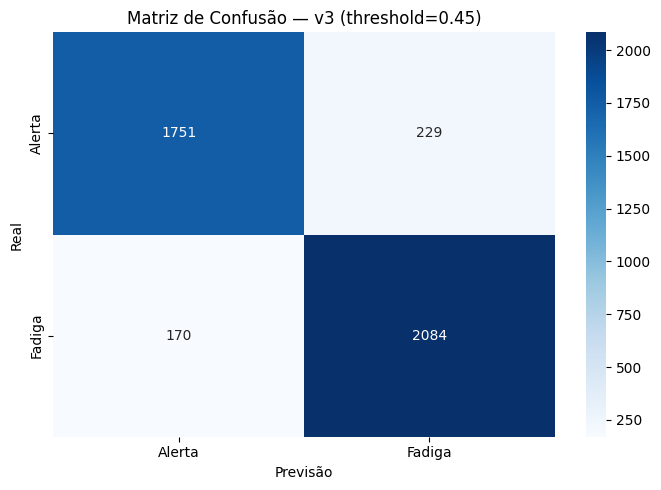

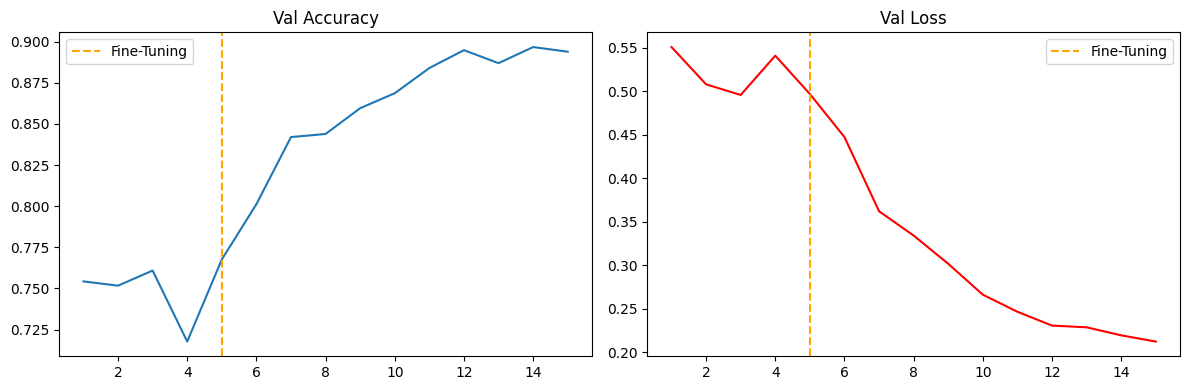

In [9]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

model_final = tf.keras.models.load_model('melhor_modelo_v3.keras')

# Avalia com threshold 0.45 (mesmo que o app)
THRESHOLD = 0.45
y_true, y_pred, y_scores = [], [], []

for images, labels in test_ds:
    preds = model_final.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_scores.extend(preds.flatten())
    y_pred.extend((preds > THRESHOLD).astype(int).flatten())

print(f'Avaliado {len(y_true)} imagens | Threshold: {THRESHOLD}')
print(classification_report(y_true, y_pred, target_names=['Alerta', 'Fadiga']))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alerta', 'Fadiga'],
            yticklabels=['Alerta', 'Fadiga'])
plt.xlabel('Previsão'); plt.ylabel('Real')
plt.title(f'Matriz de Confusão — v3 (threshold={THRESHOLD})')
plt.tight_layout()
plt.savefig('matriz_confusao_v3.png', dpi=150)
plt.show()

# Evolução do treino
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
all_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss = history1.history['val_loss']     + history2.history['val_loss']
fase1_end = len(history1.history['val_accuracy'])
epochs = range(1, len(all_acc) + 1)

axes[0].plot(epochs, all_acc)
axes[0].axvline(x=fase1_end, color='orange', linestyle='--', label='Fine-Tuning')
axes[0].set_title('Val Accuracy'); axes[0].legend()

axes[1].plot(epochs, all_loss, color='red')
axes[1].axvline(x=fase1_end, color='orange', linestyle='--', label='Fine-Tuning')
axes[1].set_title('Val Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('evolucao_treino_v3.png', dpi=150)
plt.show()

##  PASSO 9 — Exportar para TFLite

In [10]:
import tensorflow as tf

model_final = tf.keras.models.load_model('melhor_modelo_v3.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model_final)
tflite_model = converter.convert()

with open('modelo_fadiga.tflite', 'wb') as f:
    f.write(tflite_model)

print(f' modelo_fadiga.tflite exportado! ({len(tflite_model)/1024:.0f} KB)')

Saved artifact at '/tmp/tmp4sqcr4_8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 168, 168, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140168949075984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949077136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949076944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949076560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949077712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949076176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949077328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949077520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949075792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140168949078672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1401689490780

## 💾 PASSO 10 — Download

In [11]:
from google.colab import files

files.download('modelo_fadiga.tflite')
files.download('matriz_confusao_v3.png')
files.download('evolucao_treino_v3.png')

print(' Ficheiros descarregados!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Ficheiros descarregados!
